In [29]:
#from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

import oreonspy as op

# Dynamics of fields in a Fabry-Perot cavity

The dynamics are described by the difference equation (Rakhmanov Eq. 1.50):

$E(t) = t_a E_\mathrm{in}(t) + r_a r_b e^{-2 i k d(t)} E(t-2T)$

where:
* $t_a$ is the transmissivity of the input mirror;
* $E_\mathrm{in}(t)$ is input laser field;
* $r_a$ and $r_b$ are the reflectivities of the mirrors (a - input, b - output);
* $k = \omega / c = 2\pi / \lambda$ is the wavenumber;
* $d(t) = L + x_b(t-T) - x_a(t) = L + \xi$ is physical length of the cavity (Rakhmanov Eq. 1.33);
* $T = \frac{L}{c}$ is half of the round-trip time;
* $L$ is half of the round-trip;
* $E(t-2T)$ is the field inside the cavity at the time before one round-trip.

## Finesse and cavity decay time

Coefficient of finesse:

$F = \frac{4 r_a r_b}{(1 - r_a r_b)^2}$

$\tau_s = \frac{FL}{c\pi}$

Finesse ($\mathcal{F}$) of the cavity:

$\mathcal{F} = \frac{\pi}{2} \sqrt{F}$

Approximately: $\mathcal{F} = \pi N_\mathrm{eff}$

## Cavity gain

$E = g A$

where $g$ ia the amplitude gain of the Fabry-Perot cavity:

$g = \frac{t_a}{1-r_a r_b}$

Power gain:

$P = g^2 P_\mathrm{in}$

In [30]:
# LASER
E_in_avg = 1  #
lambd = 1064e-9  # m
k = 2.*np.pi / lambd

In [31]:
def v_cr(cavity):
    return lambd / (2. * cavity.Finesse() * cavity.tau())  # In [m/s]!

In [32]:
def time_window(v, cavity, number_of_FSR=2.):
    t_stop = number_of_FSR * lambd/(2.*v)
    print("Time window [s]: {0}".format(t_stop))
    number_of_points = int(np.ceil(t_stop/cavity.Theta))
    print("Time window point number: {0}".format(number_of_points))
    return number_of_points, np.linspace(0., t_stop, number_of_points)


## Pound-Drever-Hall $V_\mathrm{pdh}$

In [33]:
gamma = np.pi/2

def V_pdh(gamma, E_in, E):
    """
    Calculate the Pound-Drever-Hall error signal. Based on the formula: 2.83 (Rakhmanov).

    Parameters:
    gamma (float): Demodulation phase of the coherent detection.
    E_in (complex): Input electric field.
    E (complex): Electric field inside the cavity.

    Returns:
    float: Pound-Drever-Hall error signal.
    """
    return -(np.exp(gamma*1.j) * np.conjugate(E_in) * E).imag

In [34]:
E_in_init = 1.*np.exp(0.2j)
print("E_in_init: {0}".format(E_in_init))
print("E_in_init_abs", np.abs(E_in_init))
print("E_in_init_phase", np.angle(E_in_init))

ARM = op.Cavity(t_a = 0.1, r_a = 0.9, r_b = 0.9, L=3., debug=False)
ARM.simulation(k, 1500000e3, E_in_init=E_in_init)
print("E_in_init: {0}".format(ARM.E_in_buffers))
print("E_in_init mag: {0}".format(np.abs(ARM.E_in_buffers)))
print("E_in_init angle: {0}".format(np.angle(ARM.E_in_buffers)))
print("E_last: {0}".format(ARM.E_last))
print("E_last mag: {0}".format(np.abs(ARM.E_last)))
print("E_last angle: {0}".format(np.angle(ARM.E_last)))
print("airy_phi mag: {0}".format(np.abs(ARM.airy_phi)))
print("airy_phi angle: {0}".format(np.angle(ARM.airy_phi)))
ARM.print_sim_params()
#TEst.plot_sim_factors()

INFO:oreonspy.oreonspy:2T x times bigger then Theta. (x is integer)


E_in_init: (0.9800665778412416+0.19866933079506122j)
E_in_init_abs 1.0
E_in_init_phase 0.2
E_in_init: [deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.19866933079506122j)], maxlen=1), deque([(0.9800665778412416+0.

Time window [s]: 2.978306083826075e-06
Time window point number: 4468
Last mag: 0.07566773665570317
Last phase: 0.8284320824101559
(0.06003509210256666+0.04724235511362868j)
(0.738426881009581-0.33413185902825493j)
(0.4671730642090564-0.42893159932502756j)


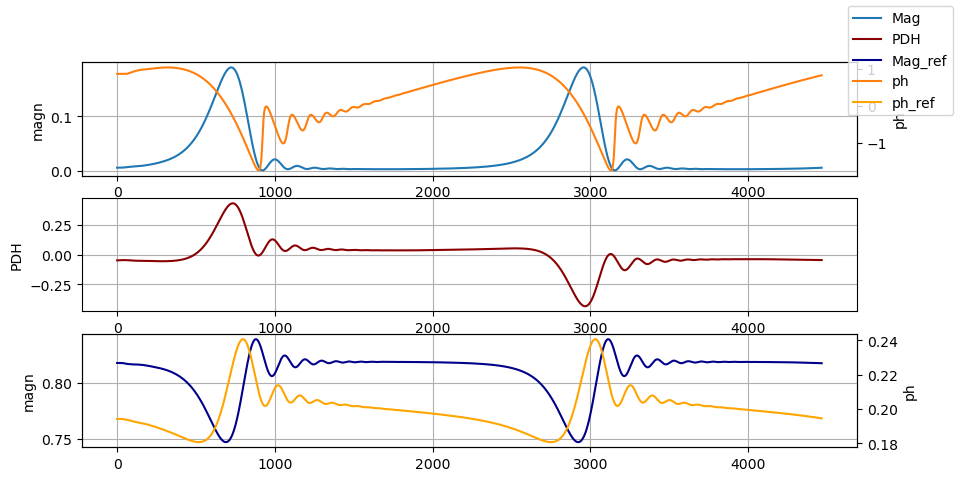

In [35]:
v = 1*v_cr(ARM)
d_zeta = v*ARM.Theta

points, tdata = time_window(v, ARM)
s = np.zeros(points)
s_ref = np.zeros(points)
ph = np.zeros(points)
ph_ref = np.zeros(points)
pdh = np.zeros(points)
ph_step = 2.*np.pi/points
for i in range(points):
    #d_zeta = 0.
    #x = TEst.sim_step(d_zeta, E_in_curr=E_in_init)
    E_in_curr = E_in_init*np.exp(ph_step*1.j*i)
    #E_in_curr = 1.
    #x = TEst.sim_2mirr(d_zeta_2=d_zeta, d_zeta_1=d_zeta, E_in_curr=E_in_curr)
    E, E_ref = ARM.sim_step(d_zeta=d_zeta, d_zeta_in=0., E_in_laser=E_in_init)
    s[i] = np.abs(E)**2
    s_ref[i] = np.abs(E_ref)**2
    ph[i] = np.angle(E)
    ph_ref[i] = np.angle(E_ref)
    pdh[i] = V_pdh(0., E_in_curr, E)
    

#    print(TEst.E_last)

print("Last mag: {0}".format(np.abs(E)))
print("Last phase: {0}".format(np.angle(E)))
#print(d_zeta)

phi = ARM.airy_phi
print(phi)
print(ARM.Airy(phi=phi))
print(ARM.E_adiabatic(1., phi=phi))

#fig = plt.figure()
fig, ax = plt.subplots(3, 1)
#ax = fig.add_subplot(111)
ax[0].plot(s, label="Mag")
ax[0].grid()
ax[0].set_ylabel("magn")

#ax[1] = fig.add_subplot(212)
ax[1].plot(pdh, label="PDH", c="darkred")
ax[1].set_ylabel("PDH")
ax[1].grid()

ax[2].plot(s_ref, label="Mag_ref", color='darkblue')
ax[2].set_ylabel("magn")
ax[2].grid()

ax2 = ax[0].twinx()
ax2.plot(np.unwrap(ph), label="ph", color='tab:orange')
ax3 = ax[2].twinx()
ax3.plot(np.unwrap(ph_ref), label="ph_ref", color='orange')
ax2.set_ylabel("ph")
ax2.tick_params(axis='y')
ax3.set_ylabel("ph")
ax3.tick_params(axis='y')

fig.legend()

In [8]:
import numpy as np

# Combine s and ph into a single array
data = np.column_stack((s, ph))

# Save to CSV file
np.savetxt('s_ph_data.csv', data, delimiter=',', header='s,ph', comments='')

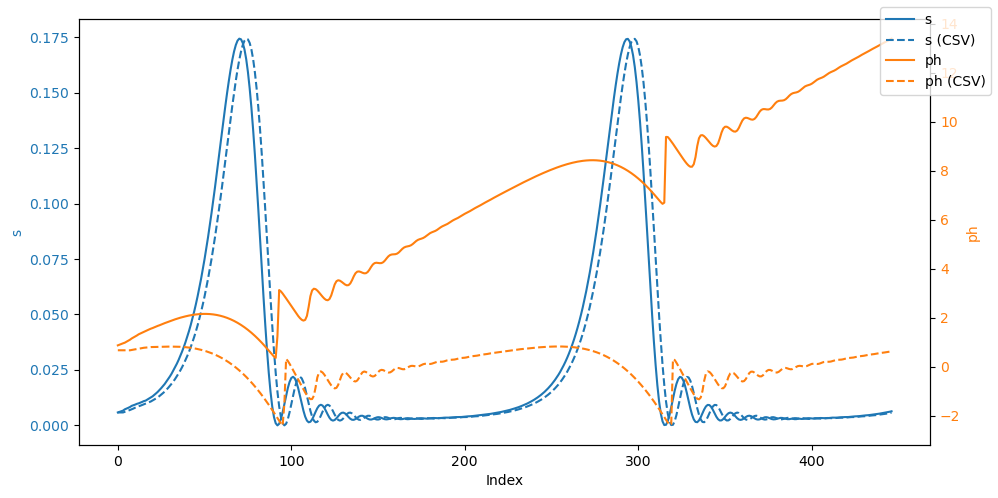

In [9]:
# Load data from CSV file
data_from_csv = np.loadtxt('s_ph_data_oreo_2.1.2.csv', delimiter=',', skiprows=1)

# Extract s and ph from CSV data
s_csv = data_from_csv[:, 0]
ph_csv = data_from_csv[:, 1]

# Plot the data
fig, ax1 = plt.subplots()

ax1.set_xlabel('Index')
ax1.set_ylabel('s', color='tab:blue')
ax1.plot(s, label='s', color='tab:blue')
ax1.plot(s_csv, label='s (CSV)', linestyle='dashed', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('ph', color='tab:orange')
ax2.plot(np.unwrap(ph), label='ph', color='tab:orange')
ax2.plot(ph_csv, label='ph (CSV)', linestyle='dashed', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.tight_layout()
fig.legend(loc='upper right')
plt.show()

### Test for ARM cavity to measure the percentage of linearity and non linearity, useful for machine learning.

In [14]:
ARM = op.Cavity(t_a = 0.01377, r_a = 0.986, r_b = 0.99999, L = 3000., debug=False)
ARM.simulation(k, 150e3, E_in_init=E_in_init)
ARM.print_sim_params()

INFO:oreonspy.oreonspy:2T x times bigger then Theta. (x is integer)


Theta: 6.67e-06 [s]
Cavity RT: 2.00e-05 [s]
Calculation frequency: 2.00e+05 [Hz]
N_eff: 7.10e+01
N: 1
Number of 2T chains: 4
Partial Theta: False


Time window [s]: 0.31640348579010336
Time window point number: 47461
Last mag: 0.00765142111132341
Last phase: -0.2335116750883405
(0.006944165840189493-0.0032158459149664734j)
(0.4507638233133866+0.22969428493863736j)
(0.46696559071226457-0.31104700374820576j)


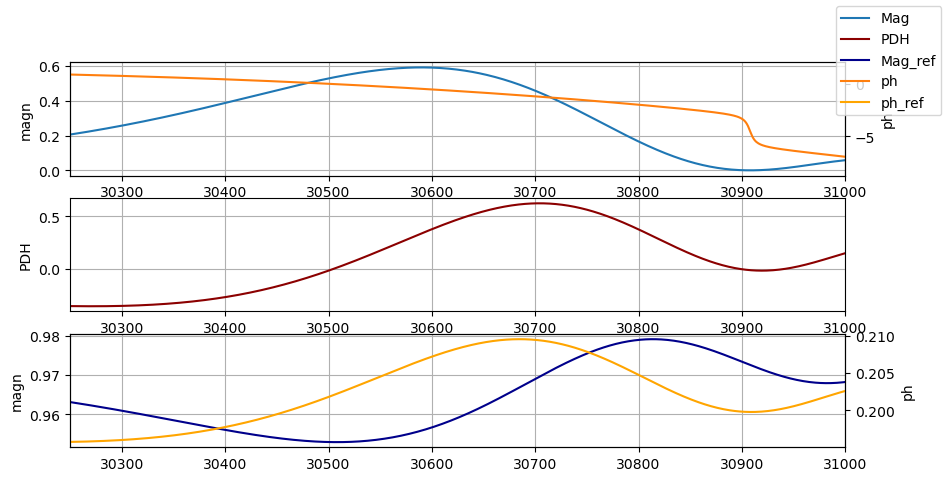

In [23]:
v = 1*v_cr(ARM)
d_zeta = v*ARM.Theta

points, tdata = time_window(v, ARM, number_of_FSR=1.)
s = np.zeros(points)
s_ref = np.zeros(points)
ph = np.zeros(points)
ph_ref = np.zeros(points)
pdh = np.zeros(points)
ph_step = 2.*np.pi/points
for i in range(points):
    #d_zeta = 0.
    #x = TEst.sim_step(d_zeta, E_in_curr=E_in_init)
    #E_in_curr = E_in_init*np.exp(ph_step*1.j*i)
    E_in_curr = 1.
    #x = TEst.sim_2mirr(d_zeta_2=d_zeta, d_zeta_1=d_zeta, E_in_curr=E_in_curr)
    E, E_ref = ARM.sim_step(d_zeta=d_zeta, d_zeta_in=0., E_in_laser=E_in_init)
    s[i] = np.abs(E)**2
    s_ref[i] = np.abs(E_ref)**2
    ph[i] = np.angle(E)
    ph_ref[i] = np.angle(E_ref)
    pdh[i] = V_pdh(0., E_in_curr, E)
    

#    print(TEst.E_last)

print("Last mag: {0}".format(np.abs(E)))
print("Last phase: {0}".format(np.angle(E)))
#print(d_zeta)

phi = ARM.airy_phi
print(phi)
print(ARM.Airy(phi=phi))
print(ARM.E_adiabatic(1., phi=phi))

#fig = plt.figure()
fig, ax = plt.subplots(3, 1)
#ax = fig.add_subplot(111)
ax[0].plot(s, label="Mag")
ax[0].grid()
ax[0].set_ylabel("magn")


#ax[1] = fig.add_subplot(212)
ax[1].plot(pdh, label="PDH", c="darkred")
ax[1].set_ylabel("PDH")
ax[1].grid()

ax[2].plot(s_ref, label="Mag_ref", color='darkblue')
ax[2].set_ylabel("magn")
ax[2].grid()

for i in range(3):
    ax[i].set_xlim(30250,31000)

ax2 = ax[0].twinx()
ax2.plot(np.unwrap(ph), label="ph", color='tab:orange')
ax3 = ax[2].twinx()
ax3.plot(np.unwrap(ph_ref), label="ph_ref", color='orange')
ax2.set_ylabel("ph")
ax2.tick_params(axis='y')
ax3.set_ylabel("ph")
ax3.tick_params(axis='y')

fig.legend()

**1500 steps * 1/150000 = machine learning useful time** 

**FSR=47461**

**200 steps * 1/150000 = linear region time**

In [28]:
dt=1/15e4
ML_time=1500 * dt
ML_FSR=47461 * dt
Linear_time=200 * dt
print ("ML_time: {0} s".format(ML_time))
print ("ML_FSR: {0} s".format(ML_FSR))
print ("Linear_time: {0} s".format(Linear_time))
ML_percent=ML_time/ML_FSR
print ("ML_percent: {0} %".format(ML_percent*100))
Linear_percent=Linear_time/ML_FSR
print ("Linear_percent: {0} %".format(Linear_percent*100))

ML_time: 0.01 s
ML_FSR: 0.31640666666666667 s
Linear_time: 0.0013333333333333333 s
ML_percent: 3.160489665198795 %
Linear_percent: 0.421398622026506 %


## Cavity parameters summary

### ARM cavity

TODO:
Verify the parameters!!!

* ifo.Optics.ITM.Transmittance  = 0.014;             % Transmittance of ITM
* ifo.Optics.ETM.Transmittance  = 5e-6;              % Transmittance of ETM
* ifo.Optics.SubstrateAbsorption = 0.3e-4;              % 1/m; bulk absorption coef
* ifo.Optics.ITM.CoatingAbsorption = 1.0e-6;            % absorption of ITM
* ifo.Materials.MassThickness = 0.2;                   % m;

In [ ]:
MassThickness = 0.2                   # m
SubstrateAbsorption = 0.3e-4          # 1/m; bulk absorption coef
MirrorSubstrateAbsorption = SubstrateAbsorption * MassThickness

t_a = 0.014
r_a = np.sqrt(1. - MirrorSubstrateAbsorption**2 - t_a**2)

t_b = 5e-6
r_b = np.sqrt(1. - t_b**2)

L = np.ceil(3000.0/lambd)*lambd - 0.05*lambd

ARM = op.Cavity(t_a = t_a, r_a = r_a, r_b = r_b, L = L, debug=False)
ARM.print_params()

In [ ]:
ARM.simulation(k, .01/ARM.T, E_last=0.0006)
ARM.print_sim_params()

In [ ]:
# ARM cavity
#here_cav.simulation(k, .01/(here_cav.T))
#v = 30*v_cr(here_cav)
#samples = 23000

v = 30*v_cr(ARM)
d_zeta = v*ARM.Theta
#points, tdata = time_window(v, ARM)
points = 23000
s = np.zeros(points)
for i in range(points):
    s[i] = np.abs(ARM.sim_step(d_zeta, E_in_curr=1.))**2

print(d_zeta)
plt.plot(s)

### Filter cavity

In [ ]:
L = np.ceil(284.9/lambd)*lambd - 0.5*lambd
FC = op.Cavity(t_a = 0.000562, r_a = 0.9998398, r_b = 0.99983999, L = L, debug=False)

'''
# Finesse 9582-10204  # Thermal detuning of a bichromatic narrow linewidth optical cavity L.D. BONAVENA
t_a = 0.000562
t_b = 0.00000316  # Thermal detuning of a bichromatic narrow linewidth optical cavity L.D. BONAVENA
r_a = np.sqrt(1. - t_a**2)-0.00016
r_b = np.sqrt(1. - t_b**2)-0.00016
L = 284.9  # m
L = 284.9  # m
'''

FC.print_params()

In [ ]:
FC.simulation(k, 100450e3)
FC.print_sim_params()

In [ ]:
v = 0.1*v_cr(FC)
d_zeta = v*FC.Theta
points, tdata = time_window(v, FC)
s = np.zeros(points)
for i in range(points):
    s[i] = np.abs(FC.sim_step(d_zeta, E_in_curr=1.))**2

print(d_zeta)
plt.plot(s)

### Mode cleaner cavity

In [ ]:
L = np.ceil(.5/lambd)*lambd - 0.05*lambd
MC = op.Cavity(t_a = 0.000562, r_a = 0.9998398, r_b = 0.99983999, L = L)

'''
'''

MC.print_params()

In [ ]:
MC.simulation(k, 1450e3)
MC.print_sim_params()

In [ ]:
v = 0.1*v_cr(MC)
d_zeta = v*MC.Theta
points, tdata = time_window(v, MC)
s = np.zeros(points)
for i in range(points):
    s[i] = np.abs(MC.sim_step(d_zeta, E_in_curr=1.))**2

print(d_zeta)
plt.plot(s)

### Virtual test cavity

In [ ]:
here_cav = FC

here_cav.simulation(k, .1/(here_cav.T))
here_cav.print_sim_params()
#TEst.plot_sim_factors()

In [ ]:
v = 2*v_cr(here_cav)
d_zeta = v*here_cav.Theta

samples = 14030

# ARM cavity
#here_cav.simulation(k, .01/(here_cav.T))
#v = 30*v_cr(here_cav)
#samples = 23000

# TEst cavity
#here_cav.simulation(k, 10/(here_cav.T))
#v = .5*v_cr(here_cav)
#samples = 10300

# FC
#here_cav.simulation(k, .1/(here_cav.T))
#v = 2*v_cr(here_cav)
#samples = 14030

s = np.zeros(samples)
Z = np.zeros(samples)



for i in range(samples):
    s[i] = np.abs(here_cav.sim_step(d_zeta, E_in_curr=1))**2
    Z[i] = here_cav.Ze[-1]
    #Z[i] = here_cav.Ze[0]
    #Z[i] = here_cav.Z

#print(d_zeta)
plt.plot(s)
#plt.plot(Z)

#plt.plot(E_in_init)

In [ ]:
v_cr(ARM)

In [ ]:
v_cr(FC)

In [ ]:
v_cr(MC)

## Airy function

In [ ]:
def Airy(F, phi):
    return 1. / (1. + F * np.sin(phi)**2)

# Cavity state sampling

This section is dedicated to the data acquisition which collects available information about the cavity such as: reflected optical power, trasmitted optical power and Pound-Drever-Hall error signal.

For efficient data treatment we consider placing the data into rolling buffers. Our first estimation of the buffer length is based on the cavity storage time $\tau$ and the sampling rate.

* sampling rate
* sampling interval
* useful past samples - considering the fact that the cavity storage time is known, there exists a maximum number of past samples usefull in the state estimation

Attempt for an efficient python circular buffer implementation:

    import collections
    d = collections.deque(maxlen=10)

    deque([], maxlen=10)
    for i in xrange(20):
        d.append(i)

In [ ]:
class cavity_sampling():
    def __init__(self, cav, sampling_rate = 100e3):
        self.cavity = cav
        self.sampling_rate = sampling_rate
        sampling_interval = 1./sampling_rate
        usefull_past_samples = int(np.ceil(cav.tau_s()/sampling_rate))
        number_of_RT_between_samples = sampling_rate*(2.*cav.T)
        print("Optimal sampling: {0:.2e} [Hz]".format(1./(2.*cav.T)))
        print("Sampling rate [SPS]: {0}".format(sampling_rate))
        print("Sampling inteval [s]: {0}".format(sampling_interval))
        print("Usefull past samples [#]: {0}".format(usefull_past_samples))
        print("Number of round-trips between samples [#]: {0}".format(number_of_RT_between_samples))

cavity_sampling(ARM, sampling_rate=68e3)
  # 100kHz

  # s

Numercal simulation needs values read by ADC at much higher sampling rate. Assuming slowly varying signals we interpolate the missing values.

In [ ]:
#np.interp()

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [ ]:
#v = 1.e-6/0.1  # m/s

v = 0.1*v_cr(ARM)
#v = 0.00037640

def d(t):
    # Constant
    #return 2

    # Linear
    #c = 1.
    return v*t + L

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [ ]:
def E_in(t):
    return 1.
    #return A*np.sin(2.*np.pi*f*t)

## Implementation of Eq. 1.51

$\large E(t) = t_a \sum_{n=0}^{N-1}(r_a r_b)^n e^{-2ikS_n(t)} E_\mathrm{in}(t-2nT) + (r_a r_b)^N e^{-2ikS_N(t)}E(t-2NT)$


### Factor common to interations, possible to pre-calculate

In [ ]:
def possible_f_calc(cav):
    for i in np.arange(2,10):
        print("One simulation with N = {0} to obtain f_calc: {1:.1f} [Hz]".format(i, 1./(2.*cav.T*i)))
        
    for i in np.arange(1,10):
        print("Make {0} simulations to obtain f_calc: {1:.1f} [Hz]".format(i, i*1./(2.*cav.T)))

possible_f_calc(MC)

## Linear cavity sweep simulation

In [ ]:
d_zeta = v*2.*ARM.T

ARM.simulation(k, 100.e3)
ARM.sim_step(d_zeta, E_in_curr=1.)

In [ ]:
def time_window(v, cavity, number_of_FSR=2.):
    t_stop = number_of_FSR * lambd/(2.*v)
    print("Time window [s]: {0}".format(t_stop))
    number_of_points = int(np.ceil(t_stop/cavity.Theta))
    print("Time window point number: {0}".format(number_of_points))
    return number_of_points, np.linspace(0., t_stop, number_of_points)

#number_of_points, tdata = time_window(v, ARM)


## Definition of useful arrays

## Automation of the comparison between numerical solution and Airy function with selectable velocity.

The function `simulation_check` aims to automatize the process of compare the numerical simulation with the analitycal solution (Airy function), giving the possibility to choose the velocity of $d(t)$ and compute the right time window for visualizing 2 free spectral range. The correct time window is calculated through the function `time_window`.

In [ ]:
def d2(t,v, type):
    if type=="const":
        return 2
    if type=="linear":
        return v*t + L
    if type=="sin":
        A = 1.e-7
        f = 200.e6  # Hz
        return A*np.sin(2.*np.pi*f*t)

In [ ]:
def simulation_check(cav, v, number_of_FSR, f_calc=10.e3):
    cav.simulation(k, f_calc)
    
    d_zeta = v*cav.Theta
    print("d_zeta: {0}".format(d_zeta))

    print("N: {0}".format(cav.N))
    
    points, tdata = time_window(v, cav, number_of_FSR=number_of_FSR)
    ein = np.zeros(points, dtype=np.complex128)
    res = np.zeros(points, dtype=np.complex128)
    Adata = np.zeros(points)
    
    for idx, t in enumerate(tdata):
        ein[idx] = E_in(t)
        res[idx] = cav.sim_step(d_zeta, E_in_curr=1.)
        Adata[idx] = Airy(cav.F(), (t*k*v))

        #print(cav.Ze)

    res = np.abs(res)
    Pdata = Adata * cav.gain()**2  # Eq. 1.76 (Rakhmanov)
    
    return tdata, ein, res, Pdata

In [ ]:
v = 2*v_cr(ARM)

tdata, E_in, E, Adata = simulation_check(ARM, v, 1, f_calc=250e3)

In [ ]:
plt.figure()
#plt.plot(tdata, np.abs(res)**2, label="Numerical magn")
#plt.plot(tdata, Adata, label="Airy")

length = len(tdata)
start_pr = int(length*0.6)
stop_pr = int(length*1)
plt.plot(E[start_pr:stop_pr]**2, label="Numerical magn")
plt.plot(Adata[start_pr:stop_pr], label="Airy")
#plt.xlim(-0.01,0.07)
plt.xlabel("Time [s]")
plt.legend()

#plt.figure()
#plt.plot(tdata, np.angle(res,deg=True), label="Numerical phase")
#plt.plot(tdata, np.angle(res, deg=True), label="Numerical phase")
#plt.xlabel("Time [s]")
#plt.legend()

plt.savefig("sampl_250kHz.png")
plt.show()

In [ ]:
ARM.plot_sim_factors()

If you want to keep your original phase with pi-periodicity, you should first double the phase, unwrap it, then divide it by two.

# TODO:
    1. 